In [1]:
pip install tensorflow pandas numpy yfinance scikit-learn matplotlib ta-lib sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install TA_Lib-0.4.28-cp311-cp311-win_amd64.whl

Processing c:\users\dmlxo\documents\github\ai-stock\models\ta_lib-0.4.28-cp311-cp311-win_amd64.whl
TA-Lib is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
Note: you may need to restart the kernel to use updated packages.


In [13]:
import numpy as np
import pandas as pd
import yfinance as yf
import talib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# AAPL 데이터 로드
ticker = "AAPL"
df = yf.download(ticker, period="3mo", interval="1d")

# 결측치 처리
df.fillna(method='ffill', inplace=True)
df.dropna(inplace=True)

# 기술 지표 계산 (수정된 부분)
def calculate_technical_indicators(df):
    # 데이터 변환
    close = df['Close'].values
    high = df['High'].values
    low = df['Low'].values
    volume = df['Volume'].values

    # 기술 지표 계산
    rsi = talib.RSI(close, timeperiod=14)
    macd, macd_signal, macd_hist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
    slowk, slowd = talib.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
    cci = talib.CCI(high, low, close, timeperiod=14)
    mfi = talib.MFI(high, low, close, volume, timeperiod=14)
    adx = talib.ADX(high, low, close, timeperiod=14)
    sma = talib.SMA(close, timeperiod=14)
    ema = talib.EMA(close, timeperiod=14)
    wma = talib.WMA(close, timeperiod=14)
    upperband, middleband, lowerband = talib.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
    sar = talib.SAR(high, low, acceleration=0.02, maximum=0.2)
    atr = talib.ATR(high, low, close, timeperiod=14)
    natr = talib.NATR(high, low, close, timeperiod=14)
    trange = talib.TRANGE(high, low, close)
    obv = talib.OBV(close, volume)
    ad = talib.AD(high, low, close, volume)
    adosc = talib.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

    # DataFrame 생성
    ind = pd.DataFrame({
        'RSI': rsi,
        'MACD': macd,
        'MACD_Signal': macd_signal,
        'MACD_Hist': macd_hist,
        '%K': slowk,
        '%D': slowd,
        'CCI': cci,
        'MFI': mfi,
        'ADX': adx,
        'SMA': sma,
        'EMA': ema,
        'WMA': wma,
        'UpperBand': upperband,
        'MiddleBand': middleband,
        'LowerBand': lowerband,
        'SAR': sar,
        'ATR': atr,
        'NATR': natr,
        'TRANGE': trange,
        'OBV': obv,
        'AD': ad,
        'ADOSC': adosc
    }, index=df.index)

    # 결측치 제거
    ind.dropna(inplace=True)
    
    return ind

# 기술 지표 계산
ind = calculate_technical_indicators(df)

# 사용 가능한 기술 지표 컬럼 정의
columns = ind.columns.tolist()

# 사용자로부터 입력 받을 컬럼 선택
print("사용 가능한 컬럼:", columns)
selected_columns = input("사용할 지표 컬럼을 쉼표로 구분하여 입력하세요: ").split(',')
selected_columns = [col.strip() for col in selected_columns if col.strip() in columns]

if not selected_columns:
    raise ValueError("올바른 컬럼을 선택하지 않았습니다.")

# 데이터 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
norm_data = scaler.fit_transform(ind[selected_columns])

# LSTM 입력 형성 (10일 데이터를 입력으로 사용)
X, y = [], []
sequence_length = 10
for i in range(len(norm_data) - sequence_length):
    X.append(norm_data[i:i + sequence_length])
    y.append(norm_data[i + sequence_length, -1])  # 마지막 컬럼을 타겟으로 설정

X = np.array(X)
y = np.array(y)

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 모델 설계
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# 모델 훈련
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# 예측
predicted = model.predict(X_test)
predicted = scaler.inverse_transform(np.concatenate((predicted, np.zeros((predicted.shape[0], len(selected_columns) - 1))), axis=1))[:, 0]

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], len(selected_columns) - 1))), axis=1))[:, 0], label='Actual')
plt.plot(range(len(predicted)), predicted, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_10544\2139276434.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Exception: input array has wrong dimensions

In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
import talib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

def fetch_stock_data(ticker='AAPL', period='1y', interval='1d'):
    """
    주식 데이터를 가져오는 함수
    
    Args:
        ticker (str): 주식 티커 심볼
        period (str): 데이터 기간 (예: '1y', '6mo', '3mo')
        interval (str): 데이터 간격 (예: '1d', '1h')
    
    Returns:
        pandas.DataFrame: 주식 데이터
    """
    try:
        # yfinance를 사용하여 주식 데이터 다운로드
        stock_data = yf.download(ticker, period=period, interval=interval)
        
        # 결측치 처리
        stock_data.fillna(method='ffill', inplace=True)
        
        return stock_data
    except Exception as e:
        print(f"데이터 다운로드 중 오류 발생: {e}")
        return None

def calculate_technical_indicators(stock_data):
    """
    기술 지표를 계산하는 함수
    
    Args:
        stock_data (pandas.DataFrame): 주식 데이터
    
    Returns:
        pandas.DataFrame: 기술 지표가 추가된 데이터프레임
    """
    # 데이터 준비
    close = stock_data['Close'].values
    high = stock_data['High'].values
    low = stock_data['Low'].values
    volume = stock_data['Volume'].values

    # 지표 계산 시 길이 동기화
    min_length = min(len(close), len(high), len(low), len(volume))
    close = close[:min_length]
    high = high[:min_length]
    low = low[:min_length]
    volume = volume[:min_length]

    # 다양한 기술 지표 계산
    indicators = {
        'RSI': talib.RSI(close, timeperiod=14),
        'MACD': talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)[0],
        'MACD_Signal': talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)[1],
        'MACD_Hist': talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)[2],
        'SlowK': talib.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)[0],
        'SlowD': talib.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)[1],
        'CCI': talib.CCI(high, low, close, timeperiod=14),
        'MFI': talib.MFI(high, low, close, volume, timeperiod=14),
        'ADX': talib.ADX(high, low, close, timeperiod=14),
        'SMA': talib.SMA(close, timeperiod=14),
        'EMA': talib.EMA(close, timeperiod=14),
        'WMA': talib.WMA(close, timeperiod=14),
        'UpperBB': talib.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)[0],
        'MiddleBB': talib.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)[1],
        'LowerBB': talib.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)[2],
        'SAR': talib.SAR(high, low, acceleration=0.02, maximum=0.2),
        'ATR': talib.ATR(high, low, close, timeperiod=14),
        'NATR': talib.NATR(high, low, close, timeperiod=14),
        'TRANGE': talib.TRANGE(high, low, close),
        'OBV': talib.OBV(close, volume),
        'AD': talib.AD(high, low, close, volume),
        'ADOSC': talib.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)
    }

    # 원본 데이터프레임 복사 및 지표 추가
    stock_data_with_indicators = stock_data.copy()
    
    # 각 지표를 데이터프레임에 추가
    for name, values in indicators.items():
        stock_data_with_indicators[name] = values

    # 결측치 제거
    return stock_data_with_indicators.dropna()

def prepare_lstm_data(stock_data_with_indicators, target_column='Close', sequence_length=10, test_size=0.2):
    """
    LSTM 모델을 위한 데이터 준비 함수
    
    Args:
        stock_data_with_indicators (pandas.DataFrame): 기술 지표가 추가된 데이터프레임
        target_column (str): 예측 대상 컬럼
        sequence_length (int): LSTM 입력 시퀀스 길이
        test_size (float): 테스트 데이터 비율
    
    Returns:
        tuple: 훈련 및 테스트 데이터 세트
    """
    # 사용할 컬럼 선택
    columns = [col for col in stock_data_with_indicators.columns if col != target_column]
    
    # 데이터 정규화
    scaler = MinMaxScaler(feature_range=(0, 1))
    norm_data = scaler.fit_transform(stock_data_with_indicators[columns])
    
    # LSTM 입력 형성
    X, y = [], []
    for i in range(len(norm_data) - sequence_length):
        X.append(norm_data[i:i + sequence_length])
        y.append(stock_data_with_indicators[target_column].values[i + sequence_length])
    
    X = np.array(X)
    y = np.array(y)
    
    # 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)
    
    return X_train, X_test, y_train, y_test, scaler

def build_lstm_model(input_shape):
    """
    LSTM 모델 생성 함수
    
    Args:
        input_shape (tuple): 입력 데이터 형상
    
    Returns:
        tensorflow.keras.Model: LSTM 모델
    """
    model = Sequential([
        LSTM(50, return_sequences=False, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def predict_stock_indicator():
    """
    주식 지표 예측 메인 함수
    
    Returns:
        tuple: 결과 데이터, 현재 가치, 예측 가치
    """
    # 주식 데이터 가져오기
    stock_data = fetch_stock_data()
    
    # 기술 지표 계산
    stock_data_with_indicators = calculate_technical_indicators(stock_data)
    
    # 사용 가능한 지표 출력
    print("사용 가능한 지표:")
    for col in stock_data_with_indicators.columns:
        print(col)
    
    # LSTM 데이터 준비
    X_train, X_test, y_train, y_test, scaler = prepare_lstm_data(stock_data_with_indicators)
    
    # 모델 생성 및 훈련
    model = build_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))
    model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)
    
    # 예측
    predicted = model.predict(X_test)
    
    # 현재 가치와 예측 가치
    current_val = y_test[-1]
    predicted_val = predicted[-1][0]
    
    # 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(y_test)), y_test, label='실제 가격')
    plt.plot(range(len(predicted)), predicted, label='예측 가격')
    plt.xlabel('시간')
    plt.ylabel('가격')
    plt.legend()
    plt.title('주식 가격 예측')
    plt.show()
    
    return stock_data_with_indicators, current_val, predicted_val

# 메인 실행
result_data, current_val, predicted_val = predict_stock_indicator()

# 결과 출력
print(f"현재 가치: {current_val}")
print(f"예측 가치: {predicted_val}")
print(f"예측 오차: {abs(current_val - predicted_val)}")

[*********************100%***********************]  1 of 1 completed
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_10544\4214808031.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stock_data.fillna(method='ffill', inplace=True)


Exception: input array has wrong dimensions

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


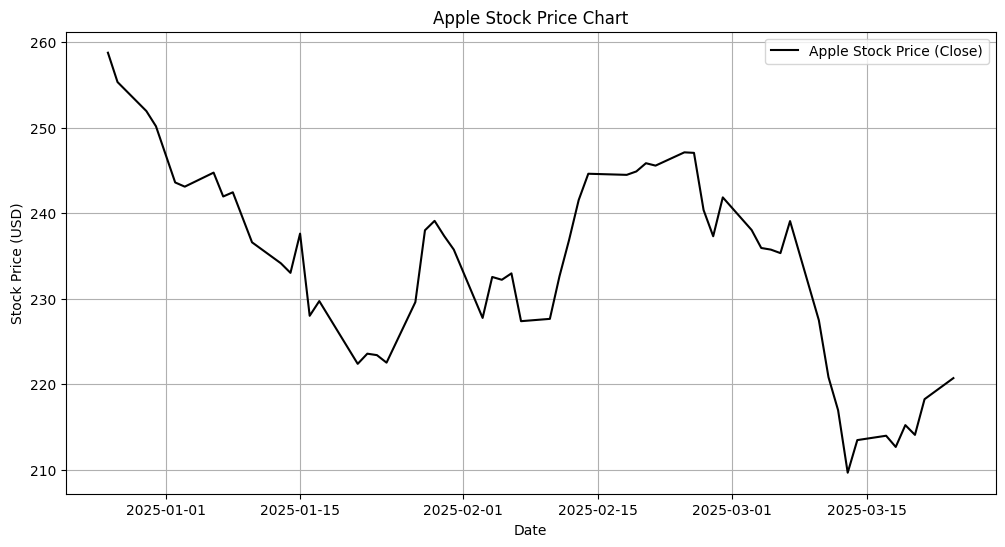

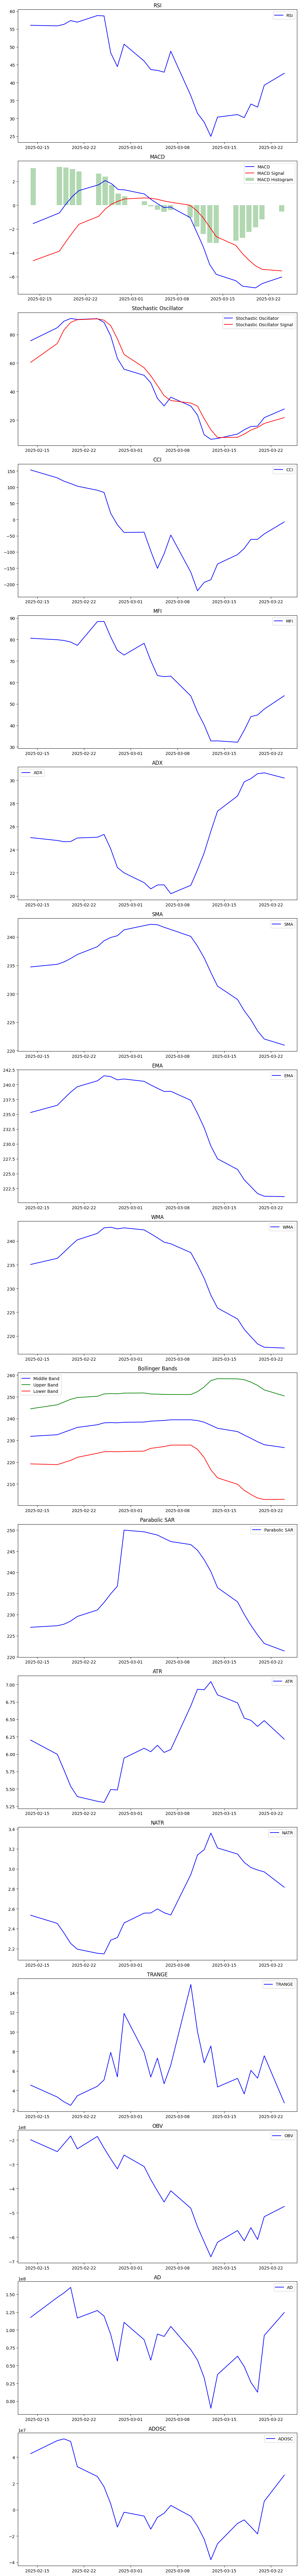

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt

# 티커 설정
ticker = "AAPL"

# 데이터 수집 (기간 조정 가능)
df = yf.download(ticker, period="3mo", interval="1d")

# 기본 컬럼 선택
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# 데이터를 np.float64 자료형의 1D numpy 배열로 변환
close = np.array(df['Close'], dtype=np.float64).ravel()
high = np.array(df['High'], dtype=np.float64).ravel()
low = np.array(df['Low'], dtype=np.float64).ravel()
volume = np.array(df['Volume'], dtype=np.float64).ravel()

# 각종 기술적 지표 계산
rsi = talib.RSI(close, timeperiod=14)
macd, macd_signal, macd_hist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
slowk, slowd = talib.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
cci = talib.CCI(high, low, close, timeperiod=14)
mfi = talib.MFI(high, low, close, volume, timeperiod=14)
adx = talib.ADX(high, low, close, timeperiod=14)
sma = talib.SMA(close, timeperiod=14)
ema = talib.EMA(close, timeperiod=14)
wma = talib.WMA(close, timeperiod=14)
upperband, middleband, lowerband = talib.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
sar = talib.SAR(high, low, acceleration=0.02, maximum=0.2)
atr = talib.ATR(high, low, close, timeperiod=14)
natr = talib.NATR(high, low, close, timeperiod=14)
trange = talib.TRANGE(high, low, close)
obv = talib.OBV(close, volume)
ad = talib.AD(high, low, close, volume)
adosc = talib.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

# 지표들을 DataFrame에 추가
ind = pd.DataFrame({
    'RSI': rsi,
    'MACD': macd,
    'MACD_Signal': macd_signal,
    'MACD_Hist': macd_hist,
    '%K': slowk,
    '%D': slowd,
    'CCI': cci,
    'MFI': mfi,
    'ADX': adx,
    'SMA': sma,
    'EMA': ema,
    'WMA': wma,
    'UpperBand': upperband,
    'MiddleBand': middleband,
    'LowerBand': lowerband,
    'SAR': sar,
    'ATR': atr,
    'NATR': natr,
    'TRANGE': trange,
    'OBV': obv,
    'AD': ad,
    'ADOSC': adosc
}, index=df.index)

# NaN 값 제거
ind.dropna(inplace=True)

# 그래프 출력 함수 정의
def plot_indicator(ax, data, title, color='blue', additional_data=None, additional_color='red', bar_data=None):
    ax.plot(data, label=title, color=color)
    if additional_data is not None:
        ax.plot(additional_data, label=f'{title} Signal', color=additional_color)
    if bar_data is not None:
        ax.bar(data.index, bar_data, label=f'{title} Histogram', color='green', alpha=0.3)
    ax.set_title(title)
    ax.legend()
    
# Apple 주가 차트 (티커와 일치하도록 수정)
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label="Apple Stock Price (Close)", color='black')
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.title("Apple Stock Price Chart")
plt.legend()
plt.grid()
plt.show()

# 전체 그래프 생성
fig, axes = plt.subplots(nrows=17, ncols=1, figsize=(10, 85))

plot_indicator(axes[0], ind['RSI'], 'RSI')
plot_indicator(axes[1], ind['MACD'], 'MACD', additional_data=ind['MACD_Signal'], bar_data=ind['MACD_Hist'])
plot_indicator(axes[2], ind['%K'], 'Stochastic Oscillator', additional_data=ind['%D'])
plot_indicator(axes[3], ind['CCI'], 'CCI')
plot_indicator(axes[4], ind['MFI'], 'MFI')
plot_indicator(axes[5], ind['ADX'], 'ADX')
plot_indicator(axes[6], ind['SMA'], 'SMA')
plot_indicator(axes[7], ind['EMA'], 'EMA')
plot_indicator(axes[8], ind['WMA'], 'WMA')

# Bollinger Bands
axes[9].plot(ind['MiddleBand'], label='Middle Band', color='blue')
axes[9].plot(ind['UpperBand'], label='Upper Band', color='green')
axes[9].plot(ind['LowerBand'], label='Lower Band', color='red')
axes[9].set_title('Bollinger Bands')
axes[9].legend()

plot_indicator(axes[10], ind['SAR'], 'Parabolic SAR')
plot_indicator(axes[11], ind['ATR'], 'ATR')
plot_indicator(axes[12], ind['NATR'], 'NATR')
plot_indicator(axes[13], ind['TRANGE'], 'TRANGE')
plot_indicator(axes[14], ind['OBV'], 'OBV')
plot_indicator(axes[15], ind['AD'], 'AD')
plot_indicator(axes[16], ind['ADOSC'], 'ADOSC')

plt.tight_layout()
plt.show()

사용할 지표 컬럼을 쉼표로 구분하여 입력하세요:  RSI


C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.2309 - val_loss: 0.0272
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - loss: 0.2017 - val_loss: 0.0211
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - loss: 0.1752 - val_loss: 0.0159
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.1513 - val_loss: 0.0114
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - loss: 0.1297 - val_loss: 0.0077
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 0.1102 - val_loss: 0.0046
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - loss: 0.0929 - val_loss: 0.0023
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.0776 - val_loss: 7.9832e-04
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 0.0644 - val_loss: 7.2349e-05
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 0.0534 - val_loss: 2.0951e-04
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - loss: 0.0446 - val_loss: 0.0013
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - loss: 0.0384

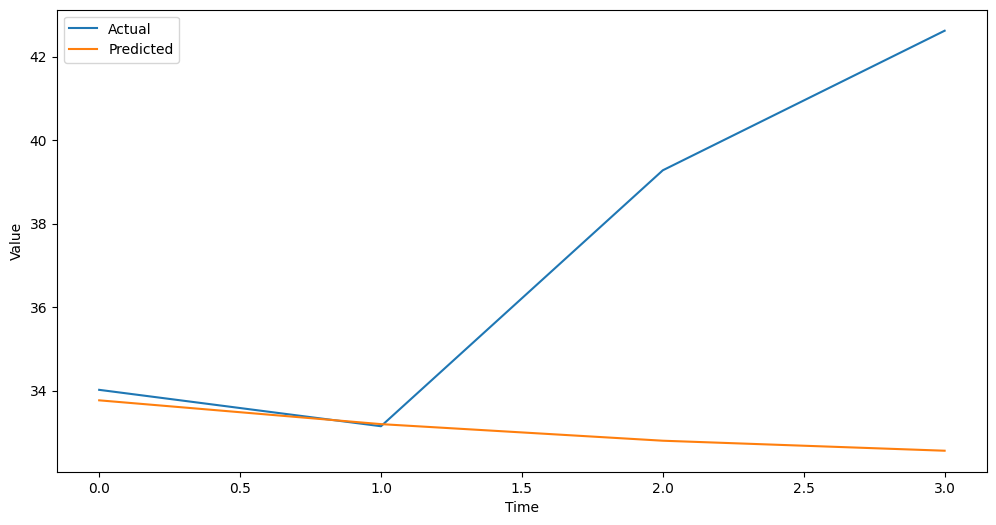

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# 사용 가능한 기술 지표 컬럼 정의
columns = ['RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', '%K', '%D', 'CCI', 'MFI', 'ADX', 'SMA', 'EMA', 'WMA', 'UpperBand', 'MiddleBand', 'LowerBand', 'SAR', 'ATR', 'NATR', 'TRANGE', 'OBV', 'AD', 'ADOSC']

# 사용자로부터 입력 받을 컬럼 선택
selected_columns = input("사용할 지표 컬럼을 쉼표로 구분하여 입력하세요: ").split(',')
selected_columns = [col.strip() for col in selected_columns if col.strip() in columns]

if not selected_columns:
    raise ValueError("올바른 컬럼을 선택하지 않았습니다.")

# 데이터 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
norm_data = scaler.fit_transform(ind[selected_columns])

# LSTM 입력 형성 (10일 데이터를 입력으로 사용)
X, y = [], []
sequence_length = 10

for i in range(len(norm_data) - sequence_length):
    X.append(norm_data[i:i + sequence_length])
    y.append(norm_data[i + sequence_length, -1])  # 마지막 컬럼을 타겟으로 설정

X = np.array(X)
y = np.array(y)

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 모델 설계
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# 모델 훈련
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# 예측
predicted = model.predict(X_test)
predicted = scaler.inverse_transform(np.concatenate((predicted, np.zeros((predicted.shape[0], len(selected_columns) - 1))), axis=1))[:, 0]

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], len(selected_columns) - 1))), axis=1))[:, 0], label='Actual')
plt.plot(range(len(predicted)), predicted, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()
